# Multi-Label Book Genre Classification (Text Based)
### **Course and Year:** TU862/2, ML/AI stream
### **Module:** Project
### **Supervisor:** Mr. Michael A Murphy
### **Group Members:** 
##### **Student 1:** Kornel Zaleski X00222004
##### **Student 2:** Blessing Mayindu X00224444
##### **Student 3:** Lukasz Kiraga X00227628
##### Goal: The goal for this project is to predict book genres based on its title and description.

In [ ]:
# !pip install numpy
# !pip install matplotlib
# !pip install scikit-learn
# !pip install scikit-multilearn
# !pip install pandas
# !pip install torch torchvision torchaudio
# !pip install transformers
# !pip install pandas 
# !pip install tabulate
# !pip install ipywidgets
# !pip install seaborn
# !pip install joblib


## Importing Necessary Libraries

In [1]:
# Importing libraries
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, hamming_loss
import joblib
import ipywidgets as widgets
import pandas as pd
import torch

# https://pytorch.org/get-started/locally/
gpu_available = torch.cuda.is_available()
if gpu_available:
    print("CUDA Version:", torch.version.cuda)
    print("GPU Name:", torch.cuda.get_device_name(0))

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import os


CUDA Version: 13.0
GPU Name: NVIDIA GeForce RTX 4060 Ti



## Data Exploration

### Analysing data through the three datasets

BooksDataset.csv loaded successfully.

-----------Dataset Shape & Columns-----------

Shape:  (103082, 5)
Columns:  ['Title', 'Author', 'Description', 'Category', 'Publisher']

-----------Description of dataset columns-----------

                 Title  Author  \
count           103082  102990   
unique           97813   63579   
top     The Nutcracker      By   
freq                12    1043   

                                              Description  \
count                                               70213   
unique                                              68831   
top     For Ingest Only - Data needs to be cleaned up ...   
freq                                                   30   

                    Category         Publisher  
count                  76911            103074  
unique                  3106             13029  
top     "Fiction", "General"  Simon & Schuster  
freq                    2549              1521   


-----------Dataset Overall Info-----------



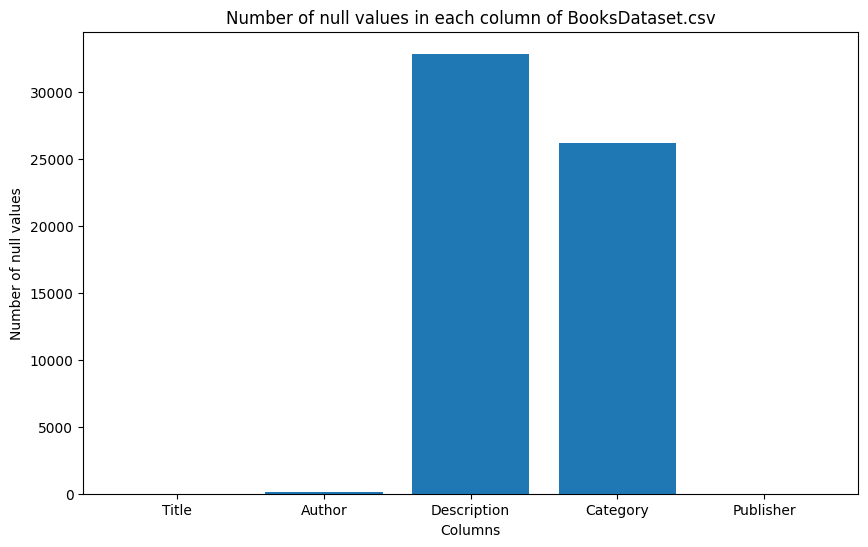

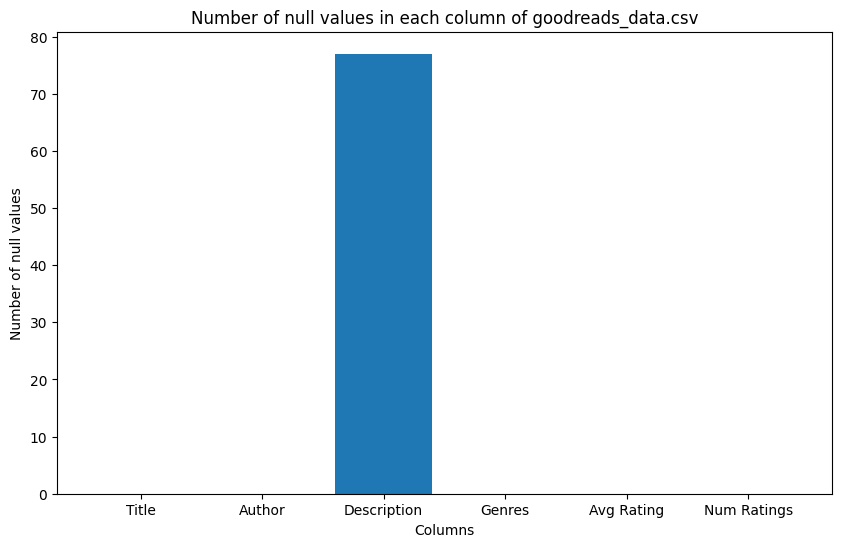

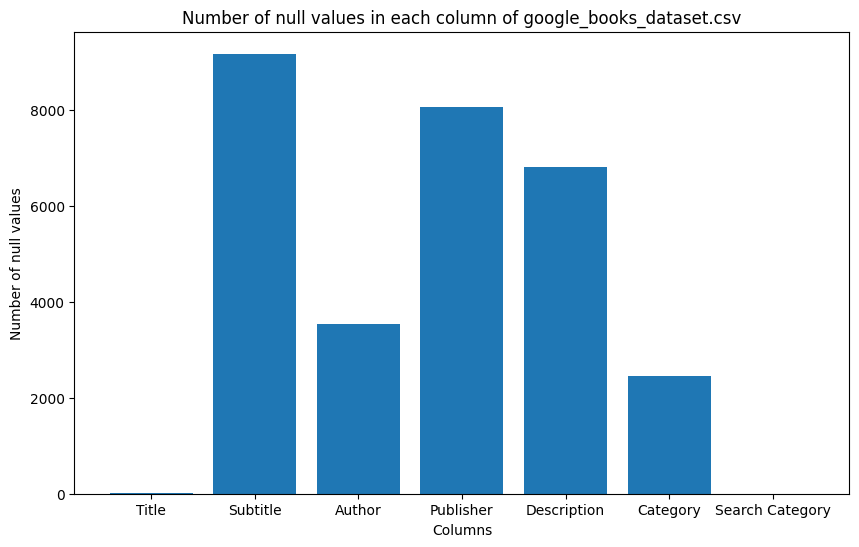

In [2]:
# BooksDataset.csv - df1
df1 = pd.read_csv('BooksDataset.csv')
print("BooksDataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df1.shape)
print("Columns: ", df1.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df1.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df1.info(), "\n")
print("\n" + ("-"*30), "\n")

# goodreads_data.csv - df2
df2 = pd.read_csv('goodreads_data.csv')
print("goodreads_data.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df2.shape)
print("Columns: ", df2.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df2.describe(include='all'), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df2.info(), "\n")
print("\n" + ("-"*30), "\n")


# google_books_dataset.csv - df3
df3 = pd.read_csv('google_books_dataset.csv')
print("google_books_dataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df3.shape)
print("Columns: ", df3.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df3.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df3.info())
print("\n" + ("-"*30), "\n")

# Number of nulls in not cleaned datasets
print("\nNull values in each uncleaned dataset\n")
print("Number of null values in BooksDataset.csv")
nulls_df1og = df1.isnull().sum()
print(nulls_df1og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in goodreads_data.csv")
nulls_df2og = df2.isnull().sum()
print(nulls_df2og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in google_books_dataset.csv")
nulls_df3og = df3.isnull().sum()
print(nulls_df3og)
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each not cleaned dataset for checking that cleaning worked as intended (checking if nan values are removed)
print("BooksDataset.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("goodreads_data.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("google_books_dataset.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

# Data visualisation of null values in not cleaned datasets

# BooksDataset.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df1og.index, nulls_df1og.values)
plt.title("Number of null values in each column of BooksDataset.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# goodreads_data.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df2og.index, nulls_df2og.values)
plt.title("Number of null values in each column of goodreads_data.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# google_books_dataset.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df3og.index, nulls_df3og.values)
plt.title("Number of null values in each column of google_books_dataset.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

## Data Cleaning
### Each dataset will be cleaned before merging


Null values in each cleaned dataset

Number of null values in BooksDatasetClean.csv
Title           0
Author         11
Description     0
Category        0
Publisher       0
dtype: int64

------------------------------ 


Number of null values in GoodreadsDatasetClean.csv
Title          0
Author         0
Description    0
Genres         0
Avg Rating     0
Num Ratings    0
dtype: int64

------------------------------ 


Number of null values in GoogleBooksDatasetClean.csv
Title                 0
Subtitle           3565
Author              299
Publisher          1135
Description           0
Category              0
Search Category       0
dtype: int64

------------------------------ 


Null values comparison (uncleaned vs cleaned)

BooksDataset.csv vs BooksDatasetClean.csv
              Uncleaned  Cleaned
Title                0        0
Author              92       11
Description      32869        0
Category         26171        0
Publisher            8        0 


----------------------

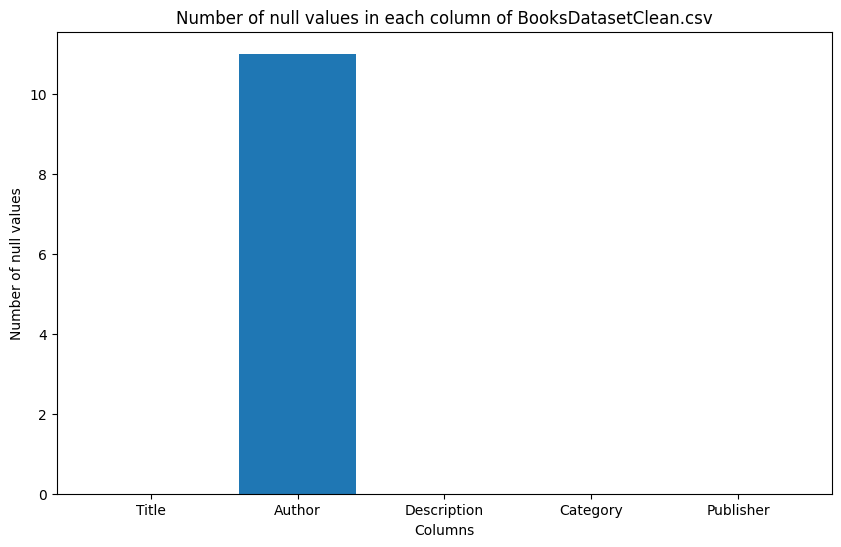

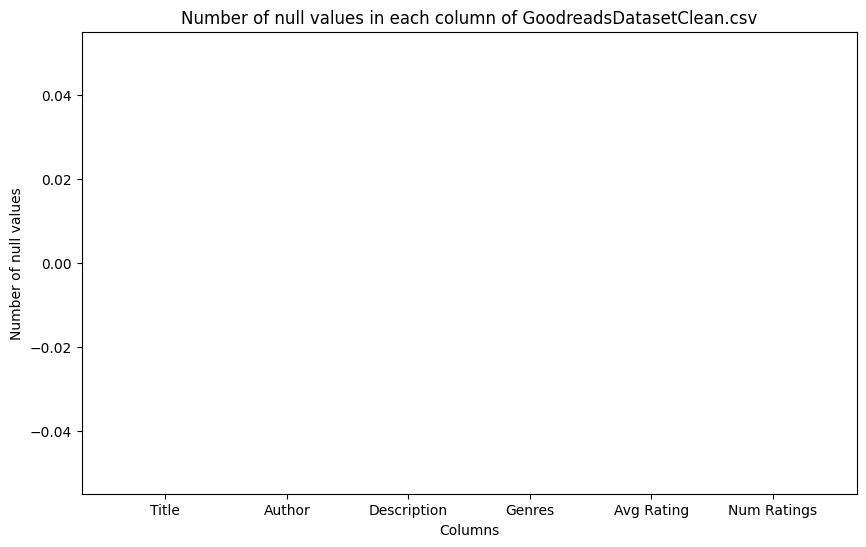

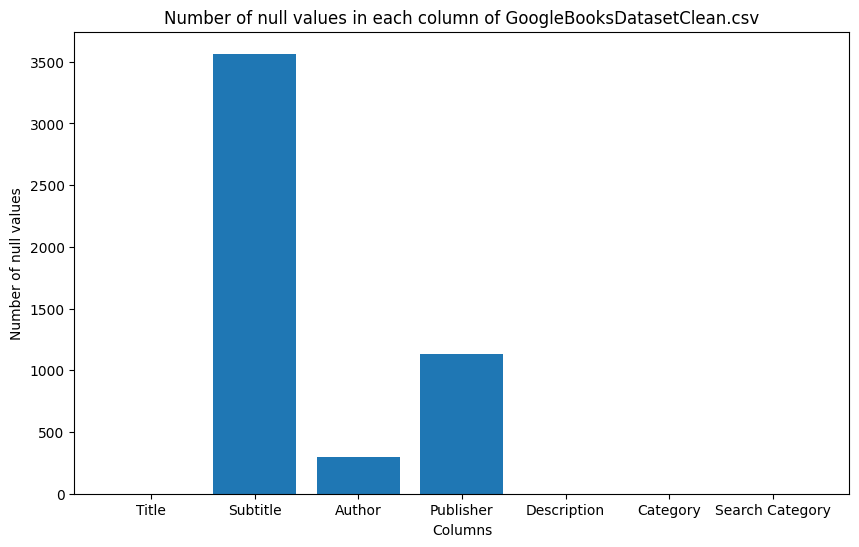

In [3]:
# Load and save the cleaned datasets

# BooksDataset.csv - df1
df1 = df1.dropna(subset=['Title', 'Description', 'Category'], how='any')
df1 = df1.drop_duplicates()

# goodreads_data.csv - df2
df2 = df2.dropna(subset=['Title', 'Description', 'Genres'], how='any')
df2 = df2.drop_duplicates()

# google_books_dataset.csv - df3
df3 = df3.dropna(subset=['Title', 'Description', 'Category'], how='any')
df3 = df3.drop_duplicates()

# Number of nulls in cleaned datasets
print("\nNull values in each cleaned dataset\n")
print("Number of null values in BooksDatasetClean.csv")
nulls_df1 = df1.isnull().sum()
print(nulls_df1)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoodreadsDatasetClean.csv")
nulls_df2 = df2.isnull().sum()
print(nulls_df2)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoogleBooksDatasetClean.csv")
nulls_df3 = df3.isnull().sum()
print(nulls_df3)
print("\n" + ("-"*30), "\n")

# Nulls in each uncleaned and cleaned datasets comparison
print("\nNull values comparison (uncleaned vs cleaned)\n")
print("BooksDataset.csv vs BooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df1og, 'Cleaned': nulls_df1}), "\n")
print("\n" + ("-"*30), "\n")
print("goodreads_data.csv vs GoodreadsDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df2og, 'Cleaned': nulls_df2}), "\n")
print("\n" + ("-"*30), "\n")
print("google_books_dataset.csv vs GoogleBooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df3og, 'Cleaned': nulls_df3}), "\n")
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each cleaned dataset to ensure the cleaning process
print("BooksDatasetClean.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("GoodreadsDatasetClean.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("GoogleBooksDatasetClean.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

# Data visualisation of null values in uncleaned datasets

# BooksDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df1.index, nulls_df1.values)
plt.title("Number of null values in each column of BooksDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# GoodreadsDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df2.index, nulls_df2.values)
plt.title("Number of null values in each column of GoodreadsDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# GoogleBooksDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df3.index, nulls_df3.values)
plt.title("Number of null values in each column of GoogleBooksDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

## Data merging


In [ ]:
# Merging two csv files
common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

final_df = pd.concat(
    [df1[common_columns], df2[common_columns], df3[common_columns]],
    ignore_index=True
)

print(final_df.head())

# Here I am showing that the columns have difference headers. To fix this I need to make them the same and then put them together.
print("DF1 columns:")
print(df1.columns.tolist())

print("\nDF2 columns:")
print(df2.columns.tolist())

print("\nDF3 columns:")
print(df3.columns.tolist())

# Making all the columns lowercase
for df in [df1, df2, df3]:
    df.columns = df.columns.str.lower().str.strip()

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)
print(common_columns)

                                               Title  \
0                         Journey Through Heartsongs   
1                       In Search of Melancholy Baby   
2       The Dieter's Guide to Weight Loss During Sex   
3  Germs : Biological Weapons and America's Secre...   
4  The Good Book: Reading the Bible with Mind and...   

                                              Author  \
0                             Stepanek, Mattie J. T.   
1  Aksyonov, Vassily, Heim, Michael Henry, and Bo...   
2                                     Smith, Richard   
3  Miller, Judith, Engelberg, Stephen, and Broad,...   
4                                    Gomes, Peter J.   

                                         Description  
0  Collects poems written the eleven-year-old mus...  
1  The Russian author offers an affectionate chro...  
2  A humor classic, this tongue-in-cheek diet pla...  
3  Deadly germs sprayed in shopping malls, bomb-l...  
4  "The Bible and the social and moral consequenc..


Common columns: Index(['title', 'description'], dtype='str')
Number of null values in each column in the merged dataset:
title                  0
authors             7403
description            0
categories          7392
publisher          11039
avg rating         72618
num ratings        72618
subtitle           78695
author             75429
category           75130
search category    75130
dtype: int64

Final merged dataset:

-----------Dataset Shape & Columns-----------

Shape:  (82522, 11)
Columns:  ['title', 'authors', 'description', 'categories', 'publisher', 'avg rating', 'num ratings', 'subtitle', 'author', 'category', 'search category']

-----------Dataset First and Last 15 rows-----------

First 15 rows

 | title                                                                  | authors                                                                 | description                                                                                                                 

Text(0, 0.5, 'Number of null values')

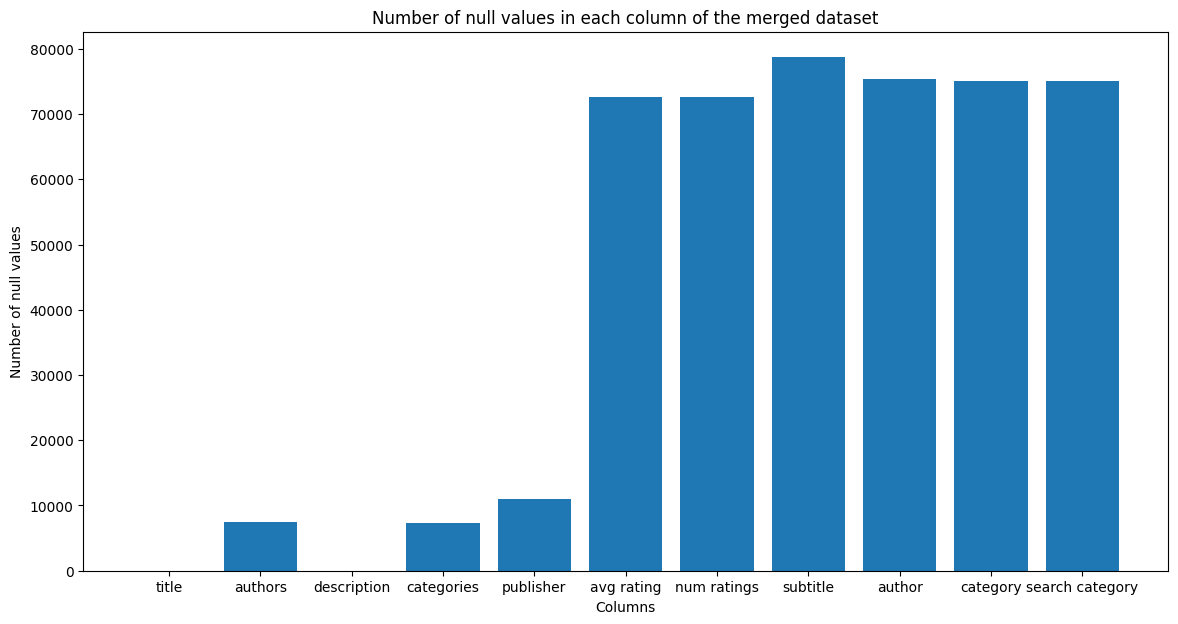

In [5]:
# Here I am matching header names to df3 
dfs = []
for df_loop in [df1, df2, df3]:
    df_loop.columns = df_loop.columns.str.lower().str.strip()
    dfs.append(df_loop)

df1,df2,df3 = dfs

df2 = df2.rename(columns={
    "book": "title",
    "author": "authors",
    "genres": "categories"
})

df1 = df1.rename(columns={
    "category": "categories",
    "author": "authors"
})

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

print("\nCommon columns:", common_columns)

# Merge
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_csv('MergedBooksDataset.csv', encoding="utf-8", index=False)

# Merged dataset info
print("Number of null values in each column in the merged dataset:\n" + str(df.isnull().sum()))

print("\nFinal merged dataset:")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())
print("\n-----------Dataset First and Last 15 rows-----------\n")
print("First 15 rows\n\n", df.head(15).to_markdown(index=False), "\n")
print("Last 15 rows\n\n", df.tail(15).to_markdown(index=False), "\n")
print("\n-----------Description of dataset columns-----------\n")
print(df.describe(), "\n")
print("\n" + ("-"*30), "\n")
print("\nNumber of categories: ")
print(df["category"].value_counts().head(20))
print("\n-----------Dataset Overall Info-----------\n")
print(df.info())
print("Number of genres:", df["category"].value_counts().sum())

# Data visualisation of null values in the merged dataset
plt.figure(figsize=(14, 7))
plt.bar(df.isnull().sum().index, df.isnull().sum().values)
plt.title("Number of null values in each column of the merged dataset")
plt.xlabel("Columns")
plt.ylabel("Number of null values")

### Data Visualisation - Categories

##### Using a bar and pie charts from matplotlib, it will show the top 10 categories that are most frequently occurring in the merged dataset

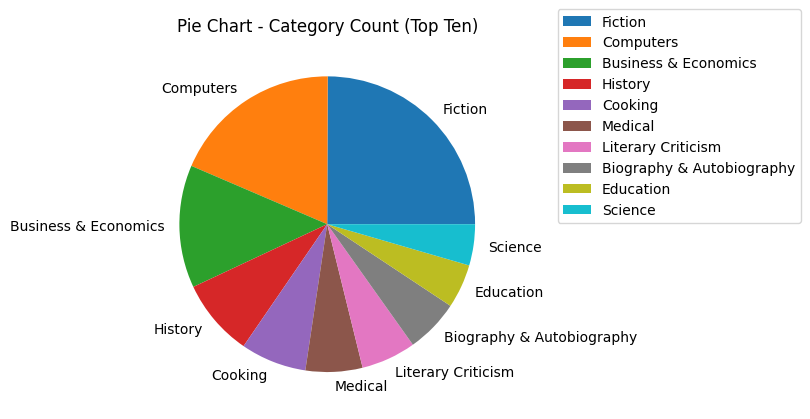

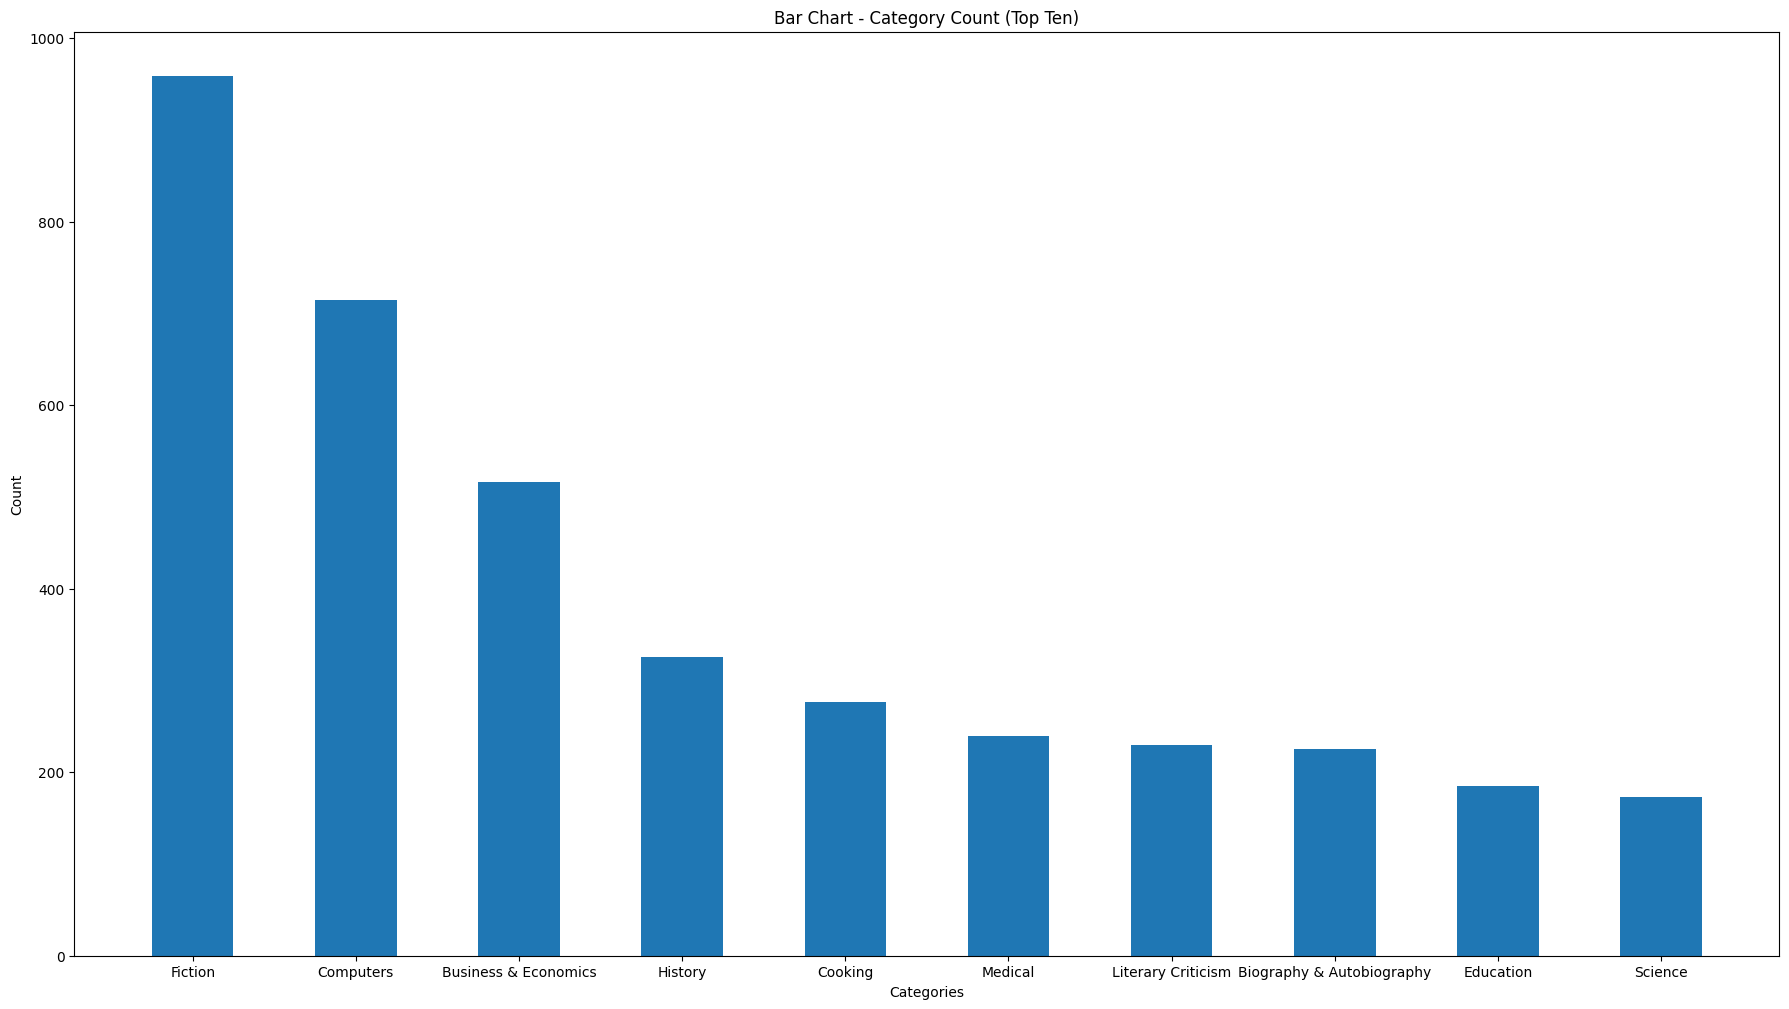

In [6]:
categories = df["category"].value_counts().head(10).index.tolist()
count = df["category"].value_counts().head(10).values.tolist()
new_categories = []

for category in categories:
    category = category.replace('"', '')
    new_categories.append(category)
    
categories = new_categories

plt.pie(count, labels=categories)
plt.title("Pie Chart - Category Count (Top Ten)")
plt.legend(categories, loc="upper right", bbox_to_anchor=(1.7, 1, 0.1, 0.1))
plt.show()

plt.figure(figsize=(22, 12))
plt.bar(categories, count, width=0.5)
plt.title("Bar Chart - Category Count (Top Ten)")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.show()

## Feature Selection

In [7]:
mlb = MultiLabelBinarizer()

# The max feature will keep the 5000 most usefull words.
# The stop word will remove useless words like 'a', 'is', etc - They are just filler words.
tfidf = TfidfVectorizer(max_features=5000 ,stop_words='english')

df = df.dropna(subset=['categories'], how='any')
texts = (df['title'] + " " + df['description'])
X = texts
categories_list = df['categories'].apply(lambda x: [category.strip().replace('"', '') for category in str(x).split(',')] if pd.notna(x) else []).tolist()
y = mlb.fit_transform(categories_list)

print("Sample of the multi-label binarised output (first 5 rows):\n", y[:5])
print("Feature matrix shape:", X.shape)
print("Number of genres:",len(mlb.classes_))
print("Genres:", mlb.classes_)


Sample of the multi-label binarised output (first 5 rows):
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Feature matrix shape: (75130,)
Number of genres: 2423
Genres: ['12th Century' '15th Century' '16th Century' ... 'etc.' 'etc.)'
 'the Gospels & Acts']


## Dataset Splits

#### We split the dataset into three sets:
 - **Training set**: fitting the models (70%)
 - **Validation set**: tuning and comparison (15%)
 - **Test set**: final unbiased evaluation (15%)

In [8]:
# Splitting the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Checking the shapes of the training, validation, and test sets
print("Training set shape: ", X_train.shape)
print("Validation set shape: ", X_val.shape)
print("Test set shape: ", X_test.shape)

# Checking the first 5 rows of training genres and the number of genres
print(mlb.inverse_transform(y_train[:5]))

Training set shape:  (52591,)
Validation set shape:  (11269,)
Test set shape:  (11270,)
[('Fiction', 'General', 'Mystery & Detective'), ('Business & Economics', 'General', 'Investments & Securities'), ('American', 'Cooking', 'Regional & Ethnic', 'Southern States'), ('Juvenile Fiction', 'Media Tie-In'), ('Boating', 'Sports & Recreation')]


## TF-IDF Vectorizer
#### We convert training, validation and test set texts into TF-IDF vectors so the ML models work 

In [9]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

## Machine Learning Models
### 1. Logistic Regression

In [10]:
# Initialise the Logistic Regression model with the maximum number of iterations as the parameter and the solver set as 'liblinear'
# We use OneVsRestClassifier wrapper for multi-label classification
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=100, solver='liblinear'))

# Fit the Logistic Regression model on the training data
log_reg.fit(X_train_tfidf, y_train)

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warni

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

### 2. Naive Bayes

In [11]:
# Initialise the Naive Bayes model with the OneVsRestClassifier wrapper for multi-label classification
naive_bayes = OneVsRestClassifier(MultinomialNB())

# Fit the Naive Bayes model on the training data
naive_bayes.fit(X_train_tfidf, y_train)

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warni

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",MultinomialNB()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Deep Learning Model

### 3. BERT (Bidirectional Encoder Representations from Transformers)
##### We now do the BERT tokenizer so we firstly take the tokenizer from huggingface, then we initialise the tokenizer for the two sets with the function and then tokenize them.

In [12]:
# BERT Tokenizer
# Initialising the tokenizer from the hugging face transformers library for the BERT model.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Function to convert the data into tokens using the tokenizer
def tokenize_data(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors='pt')

# Tokenizing the training, validation, and test data using the tokenize_data function
X_train_tokenize = tokenize_data(X_train)
X_valid_tokenize = tokenize_data(X_val)


### BERT - Model Preparation and Fitting

In [13]:
# Checks if NVIDIA GPU is available otherwise defaults to CPU
device = torch.device('cuda' if gpu_available else 'cpu')

# Custom dataset class for multi-label classification to prepare BERT
class MultiLabelBookGenreDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
    
# Creating datasets for training and validation using the class above with the tokenized text and label splits
train_dataset = MultiLabelBookGenreDataset(X_train_tokenize, y_train)
valid_dataset = MultiLabelBookGenreDataset(X_valid_tokenize, y_val)

# Initialise BERT model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(mlb.classes_),
    problem_type='multi_label_classification'
)

# If NVIDIA GPU is available it moves the model to the GPU otherwise it moves to CPU
model.to(device)
print("BERT successfully set up")
if device == torch.device('cuda'):
    print("Moved to device NVIDIA GPU CUDA -", torch.cuda.get_device_name(0))
else:
    print("Moved to device CPU by default")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT successfully set up
Moved to device NVIDIA GPU CUDA - NVIDIA GeForce RTX 4060 Ti


### Training BERT
##### To train BERT, we firstly set the training arguments then we set up the trainer using training and valid sets to train it

In [14]:
# Setting up the training arguments for the Trainer class from transformers
train_arguments = TrainingArguments(
    output_dir='./BERTresults',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    fp16=gpu_available,
    eval_strategy='epoch',
    save_strategy='epoch',    
    load_best_model_at_end=True,
    logging_dir='./logs'
)

# Create the trainer to train BERT
trainer = Trainer(model=model, args=train_arguments, train_dataset=train_dataset, eval_dataset=valid_dataset)

In [15]:
# Starts training BERT
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.006700,0.006537
2,0.006400,0.006422
3,0.006400,0.006344


TrainOutput(global_step=9861, training_loss=0.010210710562649997, metrics={'train_runtime': 2694.841, 'train_samples_per_second': 58.546, 'train_steps_per_second': 3.659, 'total_flos': 4.241417054044262e+16, 'train_loss': 0.010210710562649997, 'epoch': 3.0})

## Save Models

In [29]:
# Make saved_models directory (folder) if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save TF-IDF Vectorizer
try:
    joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.joblib')
    print("TF-IDF Vectorizer saved successfully.")
except Exception as e:
    print("Error - Could not save TF-IDF Vectorizer. Result: " + str(e) + ".")

# Save Logistic Regression model
try:
    joblib.dump(log_reg, 'saved_models/logistic_regression_model.joblib')
    print("Logistic Regression model saved successfully.")
except Exception as e:
    print("Error - Could not save Logistic Regression model. Result: " + str(e) + ".")

# Save Naive Bayes model
try:
    joblib.dump(naive_bayes, 'saved_models/naive_bayes_model.joblib')
    print("Naive Bayes model saved successfully.")
except Exception as e:
    print("Error - Could not save Naive Bayes model. Result: " + str(e) + ".")

# Save BERT model and tokenizer
try:
    trainer.save_model('saved_models/bert_model')
    tokenizer.save_pretrained('saved_models/bert_model')
    print("BERT model and tokenizer saved successfully.")
except Exception as e:
        print("Error - Could not save BERT and Tokenizer. Result: " + str(e) + ".")

TF-IDF Vectorizer saved successfully.
Logistic Regression model saved successfully.
Naive Bayes model saved successfully.
BERT model and tokenizer saved successfully.


## Load Models

In [30]:
# Load TF-IDF Vectorizer
try:
    if os.path.exists('saved_models/tfidf_vectorizer.joblib'):
        tfidf_loaded = joblib.load('saved_models/tfidf_vectorizer.joblib')
        print("TF-IDF Vectorizer loaded successfully.")
    else:
        print("Error - TF-IDF Vectorizer file not found. Unable to load.")
except Exception as e:
    print("Error - Could not load TF-IDF Vectorizer. Result: " + str(e) + ".")

# Load Logistic Regression model
try:
    if os.path.exists('saved_models/logistic_regression_model.joblib'):
        log_reg_loaded = joblib.load('saved_models/logistic_regression_model.joblib')
        print("Logistic Regression model loaded successfully.")
    else:
        print("Error - Logistic Regression model file not found. Unable to load.")
except Exception as e:
    print("Error - Could not load Logistic Regression model. Result: " + str(e) + ".")

# Load Naive Bayes model
try:
    if os.path.exists('saved_models/naive_bayes_model.joblib'):
        naive_bayes_loaded = joblib.load('saved_models/naive_bayes_model.joblib')
        print("Naive Bayes model loaded successfully.")
    else:
        print("Error - Naive Bayes model file not found. Unable to load.")
except Exception as e:
    print("Error - Could not load Naive Bayes model. Result: " + str(e) + ".")

# Load BERT model and tokenizer
try:
    if os.path.exists('saved_models/bert_model'):
        bert_loaded = BertForSequenceClassification.from_pretrained('saved_models/bert_model').to(device)
        tokenizer_loaded = BertTokenizer.from_pretrained('saved_models/bert_model')
        print("BERT model and tokenizer loaded successfully.")
    else:
        print("Error - BERT model and/or tokenizer files not found. Unable to load.")
except Exception as e:
    print("Error - Could not load BERT model and tokenizer. Result: " + str(e) + ".")

TF-IDF Vectorizer loaded successfully.
Logistic Regression model loaded successfully.
Naive Bayes model loaded successfully.
BERT model and tokenizer loaded successfully.


## Predictions | Classification Reports | Data Visualisation
### Making predictions, producing classification reports, and showing top 20 genres with the highest F1 scores. Training and evaluation losses shown in BERT.

### Logistic Regression

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

Logistic Regression - Predictions and predicted probabilities
Logistic Regression predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Logistic Regression predicted probabilities:
 [[0.00017788 0.00018041 0.00040962 ... 0.001116   0.00032912 0.00017576]
 [0.00017203 0.00017682 0.00025049 ... 0.0011397  0.00035322 0.00017248]
 [0.00017476 0.00017388 0.00024783 ... 0.00325579 0.00036272 0.00017637]
 ...
 [0.00017782 0.00018221 0.00024982 ... 0.00128777 0.00033271 0.00017312]
 [0.00018439 0.00018314 0.00026137 ... 0.00140894 0.00035331 0.00018387]
 [0.00018713 0.00018619 0.0002769  ... 0.00560709 0.00048249 0.00018704]] 

Logistic Regression - Classification Reports
Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
           

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elekt\AppData\Local\Temp\ipykernel_6648\2844279019.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')


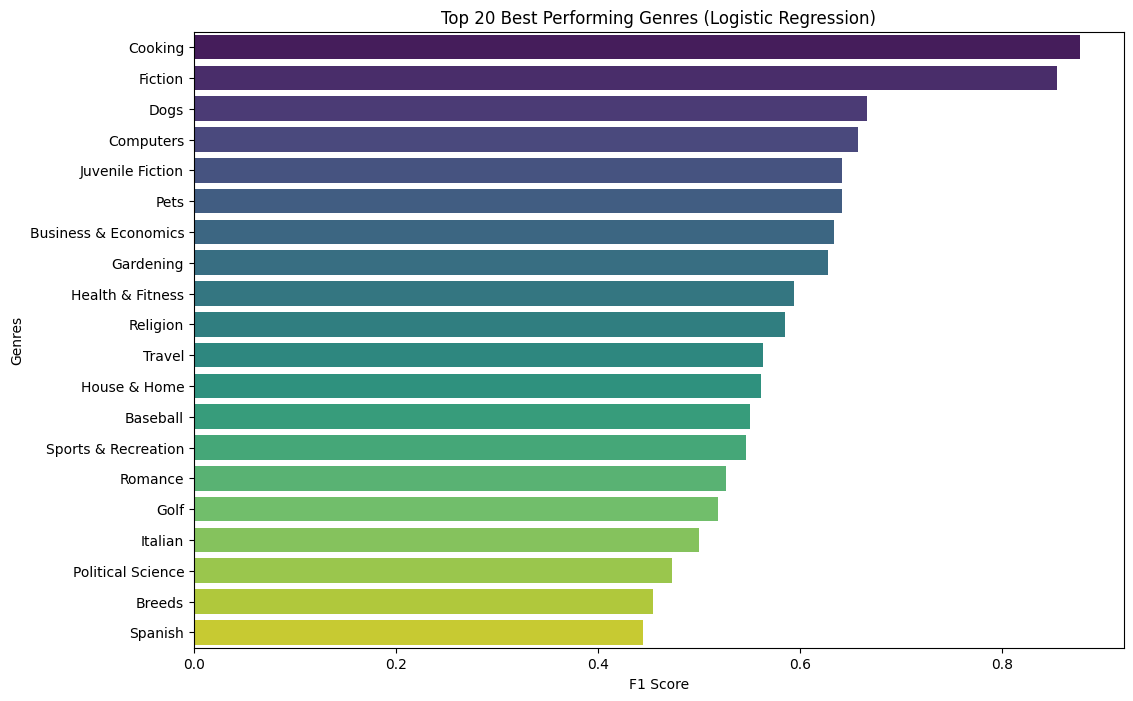

In [31]:
# Logistic Regression
try:
    # Make predictions and predicted probabilities for validation and test sets
    y_val_lr_pred = log_reg_loaded.predict(X_val_tfidf)
    y_test_lr_pred = log_reg_loaded.predict(X_test_tfidf)
    y_val_lr_proba = log_reg_loaded.predict_proba(X_val_tfidf)
    y_test_lr_proba = log_reg_loaded.predict_proba(X_test_tfidf)

    # Produce classification reports for validation and test sets
    val_classification_report_lr = classification_report(y_val, y_val_lr_pred, target_names=mlb.classes_)
    test_classification_report_lr = classification_report(y_test, y_test_lr_pred, target_names=mlb.classes_)

    print("Logistic Regression - Predictions and predicted probabilities")

    # Print predictions and predicted probabilities
    print("Logistic Regression predictions:\n", y_val_lr_pred)
    print("\n\nLogistic Regression predicted probabilities:\n", y_val_lr_proba, "\n")

    print("Logistic Regression - Classification Reports")

    # Print classification reports for validation and test sets
    print("Validation Classification Report:\n", val_classification_report_lr, "\n\n\n\nTest Classification Report:\n", test_classification_report_lr)

    # Calculating F1 scores for each genre to visualise the best performing genres
    f1_scores = f1_score(y_val, y_val_lr_pred, average=None)
    genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

    # Sort genres by F1 score and show top 20 best performing genres in a horizontal bar chart
    top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
    print("\nGenres with highest F1 scores sorted (top to bottom):\n", top_20_genres)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
    plt.title('Top 20 Best Performing Genres (Logistic Regression)')
    plt.xlabel('F1 Score')
    plt.ylabel('Genres')
    plt.show()
except Exception as e:
    print("Error - Could not make predictions nor produce classification reports with loaded Logistic Regression model. Result: " + str(e) + ".")

### Naive Bayes

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

Naive Bayes - Predictions and predicted probabilities
Naive Bayes predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Naive Bayes predicted probabilities:
 [[5.65722773e-07 5.74968180e-07 5.10466005e-06 ... 7.92430505e-05
  6.34840690e-06 5.59406532e-07]
 [3.60471616e-06 3.70519113e-06 2.19728899e-05 ... 3.92124615e-04
  4.38093193e-05 3.62204240e-06]
 [1.34587170e-06 1.34200492e-06 8.07108278e-06 ... 4.09168236e-04
  1.65472587e-05 1.36083464e-06]
 ...
 [4.05241414e-06 4.15387963e-06 2.37147885e-05 ... 4.52637736e-04
  4.44011694e-05 3.95568253e-06]
 [3.51221127e-06 3.49667874e-06 2.07911114e-05 ... 4.05819081e-04
  3.86536820e-05 3.50927483e-06]
 [3.30109648e-06 3.29436254e-06 2.03004392e-05 ... 1.02365882e-03
  4.73466686e-05 3.30484829e-06]] 

Naive Bayes - Classification Reports
Validation Classification Report:
                                                            precision    recall  f1-sco

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elekt\AppData\Local\Temp\ipykernel_6648\1703077347.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')


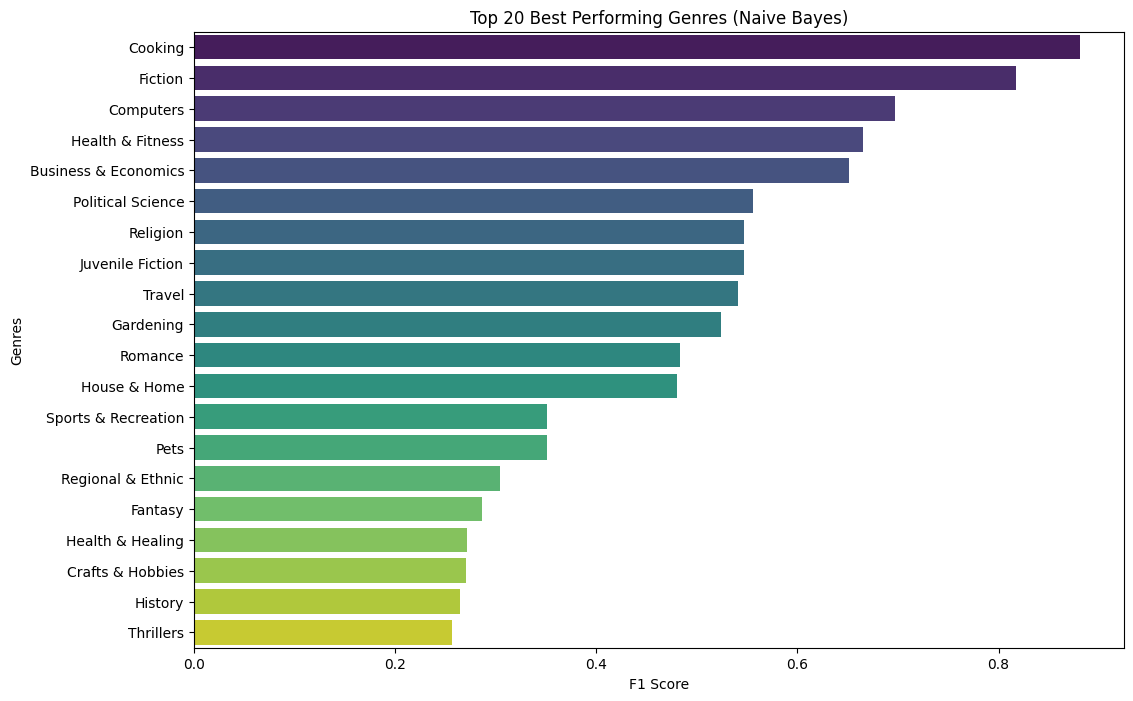

In [32]:
# Naive Bayes
try:
    # Make predictions and predicted probabilities for validation and test sets
    y_val_nb_pred = naive_bayes_loaded.predict(X_val_tfidf)
    y_test_nb_pred = naive_bayes_loaded.predict(X_test_tfidf)
    y_val_nb_proba = naive_bayes_loaded.predict_proba(X_val_tfidf)
    y_test_nb_proba = naive_bayes_loaded.predict_proba(X_test_tfidf)

    # Produce classification reports for validation and test sets
    val_classification_report_nb = classification_report(y_val, y_val_nb_pred, target_names=mlb.classes_)
    test_classification_report_nb = classification_report(y_test, y_test_nb_pred, target_names=mlb.classes_)

    print("Naive Bayes - Predictions and predicted probabilities")

    # Print predictions and predicted probabilities
    print("Naive Bayes predictions:\n", y_val_nb_pred)
    print("\n\nNaive Bayes predicted probabilities:\n", y_val_nb_proba, "\n")

    print("Naive Bayes - Classification Reports")

    # Print classification reports for validation and test sets
    print("Validation Classification Report:\n", val_classification_report_nb, "\n\n\n\nTest Classification Report:\n", test_classification_report_nb)

    # Calculating F1 scores for each genre to visualise the best performing genres
    f1_scores = f1_score(y_val, y_val_nb_pred, average=None)
    genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

    # Sort genres by F1 score and show top 20 best performing genres in a horizontal bar chart
    top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
    print("\nGenres with highest F1 scores sorted (top to bottom):\n", top_20_genres)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
    plt.title('Top 20 Best Performing Genres (Naive Bayes)')
    plt.xlabel('F1 Score')
    plt.ylabel('Genres')
    plt.show()
except Exception as e:
    print("Error - Could not make predictions nor produce classification reports with loaded Naive Bayes model. Result: " + str(e) + ".")

### BERT

BERT predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


BERT predicted probabilities:
 [[2.1995338e-04 3.6543285e-04 8.0408592e-04 ... 7.6362160e-03
  8.3935994e-04 2.3231418e-04]
 [4.5397872e-05 6.2537132e-05 1.4091856e-04 ... 1.9342611e-03
  1.9563535e-04 3.6764632e-05]
 [4.5397872e-05 6.2050494e-05 1.3982208e-04 ... 1.9267347e-03
  1.9411318e-04 3.6478537e-05]
 ...
 [4.6112749e-05 6.4020060e-05 1.4653130e-04 ... 1.9723359e-03
  1.9716943e-04 3.8229115e-05]
 [4.5044595e-05 6.2050494e-05 1.3982208e-04 ... 1.9267347e-03
  1.9411318e-04 3.6478537e-05]
 [4.5397872e-05 6.2537132e-05 1.4091856e-04 ... 1.9342611e-03
  1.9563535e-04 3.6764632e-05]]


c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

BERT - Classification Report
Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                       

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elekt\AppData\Local\Temp\ipykernel_6648\3585195160.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')



Genres with highest F1 scores sorted (top to bottom):
                        genre  f1-score
0               12th Century       0.0
1               15th Century       0.0
2               16th Century       0.0
3               17th Century       0.0
4               18th Century       0.0
5               19th Century       0.0
6               20th Century       0.0
7               21st Century       0.0
8                         A+       0.0
9                        ACT       0.0
10                AIDS & HIV       0.0
11                        AR       0.0
12  Abortion & Birth Control       0.0
13                     Abuse       0.0
14                  Academia       0.0
15                  Academic       0.0
16      Academic Development       0.0
17                Accounting       0.0
18         Acoustics & Sound       0.0
19          Acrylic Painting       0.0


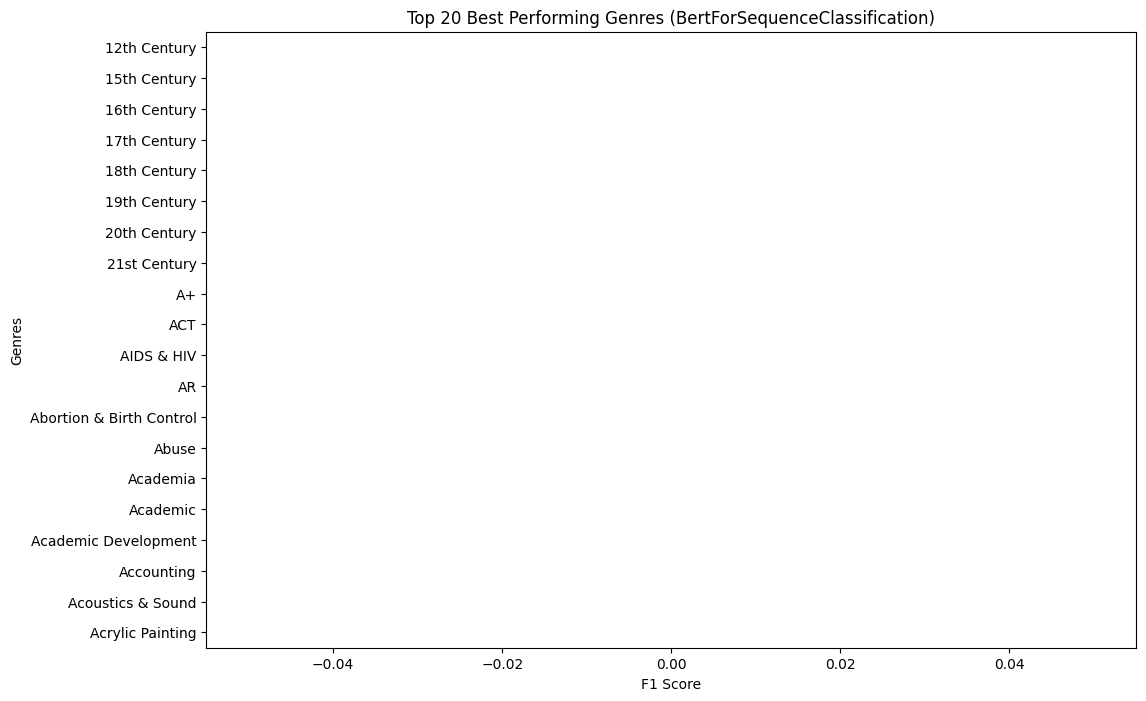

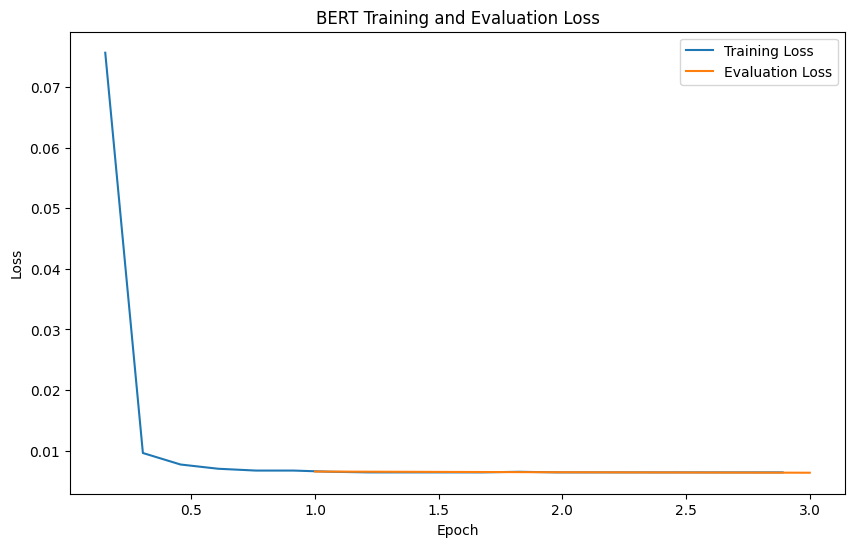

In [33]:
# BERT
try:
    bert_results = trainer.predict(valid_dataset)
    bert_logits = torch.tensor(bert_results.predictions)
    bert_proba = torch.sigmoid(bert_logits).numpy()
    bert_pred = (bert_proba >= 0.5).astype(int)
    print("BERT predictions:\n", bert_pred)
    print("\n\nBERT predicted probabilities:\n", bert_proba)

    # Produce classification report for BERT predictions
    classification_report_bert = classification_report(y_val, bert_pred, target_names=mlb.classes_)
    print("BERT - Classification Report")
    print("Classification Report:\n", classification_report_bert)
        
    # Calculating F1 scores for each genre to visualise the best performing genres
    f1_scores = f1_score(y_val, bert_pred, average=None)
    genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

    # Sort genres by F1 score and show top 20 best performing genres in a horizontal bar chart
    top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
    print("\nGenres with highest F1 scores sorted (top to bottom):\n", top_20_genres)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
    plt.title('Top 20 Best Performing Genres (BertForSequenceClassification)')
    plt.xlabel('F1 Score')
    plt.ylabel('Genres')
    plt.show()

    # History of losses after training BERT
    history = pd.DataFrame(trainer.state.log_history)

    # Training and evaluation losses
    if 'loss' in history.columns:
        train_loss = history[history['loss'].notna()][['epoch', 'loss']]
    else:
        train_loss = pd.DataFrame(columns=['epoch', 'loss'])
        print("Training loss data not found in history")
        
    if 'eval_loss' in history.columns:
        eval_loss = history[history['eval_loss'].notna()][['epoch', 'eval_loss']]
    else:
        eval_loss = pd.DataFrame(columns=['epoch', 'eval_loss'])
        print("Evaluation loss data not found in history")

    # Plotting training and evaluation losses
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss['epoch'], train_loss['loss'], label='Training Loss')
    plt.plot(eval_loss['epoch'], eval_loss['eval_loss'], label='Evaluation Loss')
    plt.title('BERT Training and Evaluation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
except Exception as e:
    print("Error - Could not prepare sample data for BERT predictions. Result: " + str(e) + ".")

## Models Comparison - Machine Learning models and a Deep Learning model

#### We compare the three models by their micro F1 scores, hamming loss, precisions and recalls. We expect the machine learning models to have lower micro F1 scores than BERT. In all models, we expect hamming loss to be at or incredibly close to zero.

C:\Users\elekt\AppData\Local\Temp\ipykernel_6648\7395163.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_scores, palette='magma')


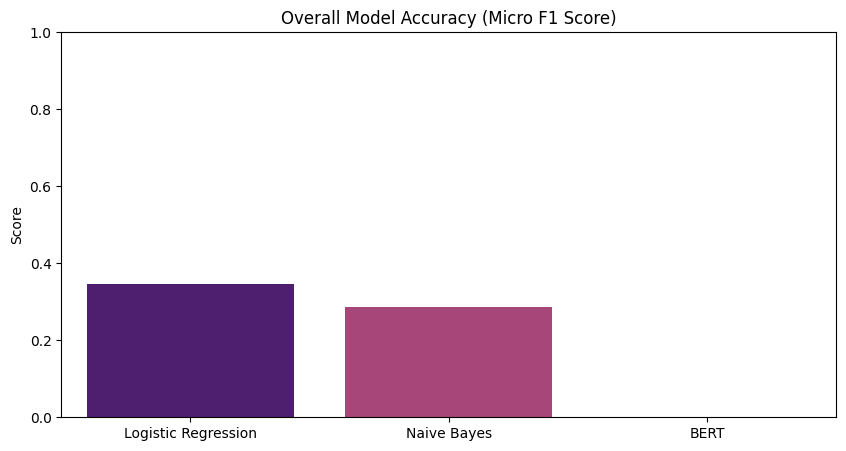

C:\Users\elekt\AppData\Local\Temp\ipykernel_6648\7395163.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=hamming_losses, palette='magma')


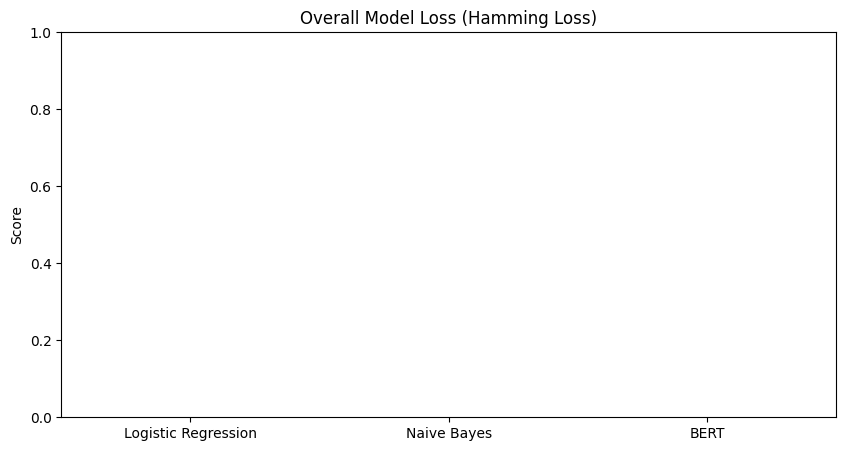

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


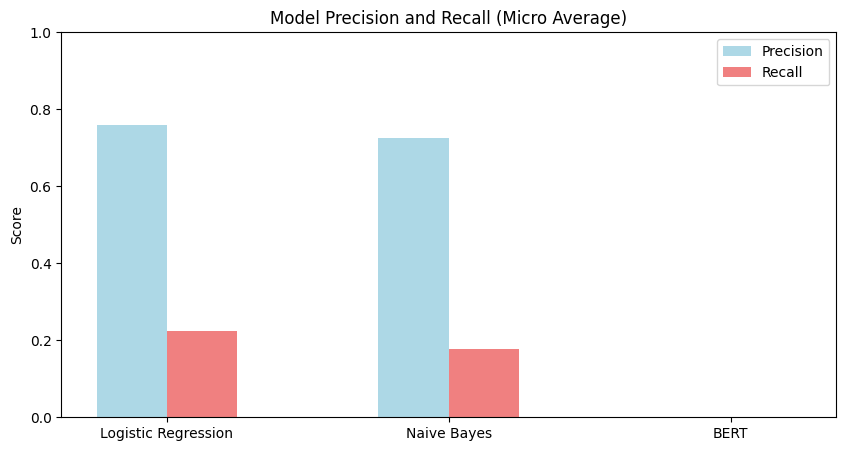

In [34]:
# Data for the model comparison graph
models = ["Logistic Regression", "Naive Bayes", "BERT"]

# F1 scores for the models to compare performance visually
try:
    f1_scores = [
        f1_score(y_val, y_val_lr_pred, average='micro'),
        f1_score(y_val, y_val_nb_pred, average='micro'),
        f1_score(y_val, bert_pred, average='micro')
    ]
    plt.figure(figsize=(10, 5))
    sns.barplot(x=models, y=f1_scores, palette='magma')
    plt.title('Overall Model Accuracy (Micro F1 Score)')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.show()
except Exception as e:
    print("Error - Could not calculate F1 scores for the models. Result: " + str(e) + ".")

# Loss score for the models to compare performance visually
try:
    hamming_losses = [
        hamming_loss(y_val, y_val_lr_pred),
        hamming_loss(y_val, y_val_nb_pred),
        hamming_loss(y_val, bert_pred)
    ]
    plt.figure(figsize=(10, 5))
    sns.barplot(x=models, y=hamming_losses, palette='magma')
    plt.title('Overall Model Loss (Hamming Loss)')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.show()
except Exception as e:
    print("Error - Could not calculate Hamming Loss for the models. Result: " + str(e) + ".")

# Precision and Recall scores for the models to compare performance visually
try:
    precision_scores = [
        precision_score(y_val, y_val_lr_pred, average='micro'),
        precision_score(y_val, y_val_nb_pred, average='micro'),
        precision_score(y_val, bert_pred, average='micro')
    ]
    recall_scores = [
        recall_score(y_val, y_val_lr_pred, average='micro'),
        recall_score(y_val, y_val_nb_pred, average='micro'),
        recall_score(y_val, bert_pred, average='micro')
    ]
    x = np.arange(len(models))
    width = 0.25
    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, precision_scores, width=width, label='Precision', color='lightblue')
    plt.bar(x + width/2, recall_scores, width=width, label='Recall', color='lightcoral')
    plt.xticks(x, models)
    plt.title('Model Precision and Recall (Micro Average)')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
except Exception as e:
    print("Error - Could not calculate Precision and Recall for the models. Result: " + str(e) + ".")


# Demo

### 1. First Sample Books Demo
#### This will predict and classify genres on all of these 5 sample books.
#### **Note:** This first demo does not have user interactivity implemented.

In [35]:
# Sample books for demo
sample_books = ["Harry Potter (Fantasy)#A young wizard discovers he has magical powers and is accepted into a school of witchcraft and wizardry where he learns about a dark wizard who murdered his parents.",
                "Murder Mystery (Crime/Thriller)#A detective investigates a series of mysterious murders in a small coastal town, uncovering dark secrets and a web of lies that leads to a shocking conclusion.",
                "Romance Novel#Two strangers meet by chance in a small Italian village and fall deeply in love, but must overcome their difficult pasts and families who disapprove of their relationship.",
                "Science Fiction#In the year 2150, a crew of astronauts embarks on a mission to colonise Mars but encounter an alien civilisation that challenges everything humanity knows about the universe.",
                "History (Non-Fiction)#A detailed account of the Second World War covering the major battles, political decisions, and the lives of soldiers and civilians caught in the conflict across Europe and the Pacific."]

print("-"*60)
print("Demo Test Results")
print("-"*60)

for i, book in enumerate(sample_books):
    print("Title: " + sample_books[i].split("#")[0])
    print("Description: " + sample_books[i].split("#")[1][:90] + "...")
    
    # Convert input texts to TF-IDF Vectors
    tfidf_input = tfidf_loaded.transform([sample_books[i]])

    # LR and NB
    lr_pred = log_reg_loaded.predict(tfidf_input)
    nb_pred = naive_bayes_loaded.predict(tfidf_input)
    lr_genres = mlb.inverse_transform(lr_pred)
    nb_genres = mlb.inverse_transform(nb_pred)
    
    # BertForSequenceClassification
    encoding = tokenizer_loaded([sample_books[i]], padding=True, truncation=True, max_length=512, return_tensors='pt')
    encoding = {k: v.to(device) for k, v in encoding.items()}
    
    bert_loaded.eval()
    with torch.no_grad():
        outputs = bert_loaded(**encoding)
        proba = torch.sigmoid(outputs.logits).cpu().numpy()
        bert_pred = (proba >= 0.5).astype(int)
        bert_genres = mlb.inverse_transform(bert_pred)
    
    # Print predicted genres for each model
    print(f"\tLogistic Regression: {', '.join(lr_genres[0]) if lr_genres[0] else 'None'}")
    print(f"\tNaive Bayes:         {', '.join(nb_genres[0]) if nb_genres[0] else 'None'}")
    print(f"\tBertForSequenceClassification: {', '.join(bert_genres[0]) if bert_genres[0] else 'None'}")
    print("-"*60)

print("\nFirst demo completed!")

------------------------------------------------------------
Demo Test Results
------------------------------------------------------------
Title: Harry Potter (Fantasy)
Description: A young wizard discovers he has magical powers and is accepted into a school of witchcraft...
	Logistic Regression: Fantasy, Fiction
	Naive Bayes:         Fantasy, Fiction
	BertForSequenceClassification: None
------------------------------------------------------------
Title: Murder Mystery (Crime/Thriller)
Description: A detective investigates a series of mysterious murders in a small coastal town, uncoverin...
	Logistic Regression: Fiction, General, Mystery, Mystery & Detective, Mystery Thriller, Suspense, Thriller, Thrillers
	Naive Bayes:         Fiction, General, Mystery & Detective, Thrillers
	BertForSequenceClassification: None
------------------------------------------------------------
Title: Romance Novel
Description: Two strangers meet by chance in a small Italian village and fall deeply in love,

### 2. Second Sample Books Demo
#### User interactivity is implemented in this second demo.
#### **Note:** This demo will only predict and classify genres on one of the sample books. This will not predict genres on the other 4 sample books.

In [36]:
# Demo for second sample list of book summaries
print("-"*60)
print("Demo Test Results - Second Sample")
print("-"*60)

sample_books = ["Diary of a Wimpy Kid: Fight or Flight#When the going gets tough, what's a wimpy kid to do? In Fight or Flight, Greg Heffley faces his biggest challenge yet as he becomes a target for the school bully. Luckily for Greg, his best friend, Rowley Jefferson, takes karate, so at least Greg's got someone in his corner. But an unexpected twist makes Greg realize he's facing an uphill battle. Will Greg step into the ring or throw in the towel? One thing's for sure - Fight or Flight is a knockout!",
                "How to Achieve Financial Freedom: A Comprehensive Guide to Building Wealth and Securing Your Future#This comprehensive guide provides practical strategies and insights to help you achieve financial freedom. From budgeting and saving to investing and retirement planning, this book covers all aspects of personal finance. Whether you're just starting your financial journey or looking to take your wealth-building efforts to the next level, this book offers valuable advice and actionable steps to help you secure your financial future.",
                "The Wonderful Wizard of Oz#The Wonderful Wizard of Oz is a children's novel written by L. Frank Baum and illustrated by W. W. Denslow. It was first published in 1900 and has since become one of the most famous and enduring works of American children's literature. The story follows a young girl named Dorothy who is swept away from her Kansas home to the magical land of Oz. Along with her dog Toto, Dorothy embarks on a journey to find the Wizard of Oz, who she believes can help her return home. Along the way, she meets memorable characters such as the Scarecrow, the Tin Woodman, and the Cowardly Lion, who join her on her quest. The novel explores themes of friendship, courage, and self-discovery, and has been adapted into numerous films, stage productions, and other media over the years. The Wonderful Wizard of Oz continues to captivate readers of all ages with its imaginative storytelling and timeless messages.",
                "Risking his heart for the ER doc#A handsome ER doctor and a brilliant heart surgeon find themselves in a whirlwind romance that defies the odds. When Dr. Emily Carter, a dedicated ER physician, meets Dr. James Anderson, a renowned heart surgeon, sparks fly instantly. As they navigate the high-stakes world of medicine together, their connection deepens, but their demanding careers threaten to pull them apart. Will their love survive the pressures of the medical field, or will they have to choose between their hearts and their careers?",
                "The Italian Foodscape: A Culinary Journey Through Italy's Regions#This book takes readers on a culinary journey through Italy's diverse regions, exploring the rich tapestry of flavors and traditions that define Italian cuisine. From the hearty dishes of the north to the vibrant flavors of the south, this book delves into the history, culture, and ingredients that make Italian food so beloved around the world. With recipes, anecdotes, and stunning photography, The Italian Foodscape celebrates the art of Italian cooking and invites readers to experience the magic of Italy's culinary heritage."]

while True:
    print("\nWelcome to the Multi-Label Book Genre Predictor. Select option 1 or 2.\n1. Random sample book between 1 and 5\n2. Manually select a sample book")
    option = int(input("Enter option (1 or 2): "))

    if option == 1:
        print("\nYou selected option 1")
        book_index = random.randint(0, len(sample_books)-1)
        break
    elif option == 2:
        print("\nYou selected option 2")
        print("\nSelect a sample book from the list below")
        for i, book in enumerate(sample_books):
            print(f"{i+1}. {book}")
        book_index = int(input("Sample book option (1-5): ")) - 1
        while book_index < 0 or book_index > len(sample_books)-1:
            print("Invalid selection.")
            book_index = int(input("Sample book option (1-5): ")) - 1
        print("\nYou selected sample book", book_index+1)
        break
    else:
        print("Invalid option - Please select 1 or 2.")

print("-"*60)
print("Sample Book", book_index+1)
print("Title: " + sample_books[book_index].split("#")[0])
print("Description: " + sample_books[book_index].split("#")[1][:90] + "...")

# Converting input texts to TF-IDF Vectors
tfidf_input = tfidf_loaded.transform([sample_books[book_index]])

# LR and NB
lr_pred = log_reg_loaded.predict(tfidf_input)
nb_pred = naive_bayes_loaded.predict(tfidf_input)
lr_genres = mlb.inverse_transform(lr_pred)
nb_genres = mlb.inverse_transform(nb_pred)

# BertForSequenceClassification
encoding = tokenizer_loaded([sample_books[book_index]], padding=True, truncation=True, max_length=512, return_tensors='pt')
encoding = {k: v.to(device) for k, v in encoding.items()}

bert_loaded.eval()
with torch.no_grad():
    outputs = bert_loaded(**encoding)
    proba = torch.sigmoid(outputs.logits).cpu().numpy()
    bert_pred = (proba >= 0.5).astype(int)
    bert_genres = mlb.inverse_transform(bert_pred)

# Print predicted genres from each
print(f"\tLogistic Regression: {', '.join(lr_genres[0]) if lr_genres[0] else 'None'}")
print(f"\tNaive Bayes:         {', '.join(nb_genres[0]) if nb_genres[0] else 'None'}")
print(f"\tBertForSequenceClassification: {', '.join(bert_genres[0]) if bert_genres[0] else 'None'}")
print("-"*60)
print("\nSecond demo completed!")

------------------------------------------------------------
Demo Test Results - Second Sample
------------------------------------------------------------

Welcome to the Multi-Label Book Genre Predictor. Select option 1 or 2.
1. Random sample book between 1 and 5
2. Manually select a sample book

You selected option 1
------------------------------------------------------------
Sample Book 2
Title: How to Achieve Financial Freedom: A Comprehensive Guide to Building Wealth and Securing Your Future
Description: This comprehensive guide provides practical strategies and insights to help you achieve fi...
	Logistic Regression: Business & Economics, Personal Finance
	Naive Bayes:         Business & Economics
	BertForSequenceClassification: None
------------------------------------------------------------

Second demo completed!


### 3. Third Sample Books Demo
#### This third demo implements user interactivity and user interface on a sample web application. You type in the title and the summary, then once you click predict, it will predict and classify genres based on the title and description typed in the fields.

In [37]:
# Demo UI
header = widgets.HTML("<h2 style='color:green'> Book Genre Predictor</h2>")
subheader = widgets.HTML("<p>Enter a book title and description below and the models will predict its genres.</p>")
title_text = widgets.HTML("<b>Title:</b>")
desc_text = widgets.HTML("<b>Description:</b>")
title_input = widgets.Textarea(placeholder='Enter a book title here...', layout=widgets.Layout(width='600px', height='30px'))
desc_input = widgets.Textarea(placeholder='Enter a book description here...', layout=widgets.Layout(width='600px', height='120px'))
predict_button = widgets.Button(description='Predict Genres', button_style='success', icon='book')

output = widgets.Output()

def predict_genres(b):
    with output:
        title = title_input.value.strip()
        description = desc_input.value.strip()
        
        if not title:
            print("Please enter a book title!")
            return
        
        if not description:
            print("Please enter a book description!")
            return
        
        title_desc = title + " " + description

        print("Predicting genres...")
        
        # Converting input texts to TF-IDF Vectors
        tfidf_input = tfidf_loaded.transform([title_desc])

        # LR and NB
        lr_pred = log_reg_loaded.predict(tfidf_input)
        lr_genres = mlb.inverse_transform(lr_pred)
        nb_pred = naive_bayes_loaded.predict(tfidf_input)
        nb_genres = mlb.inverse_transform(nb_pred)
        
        # BertForSequenceClassification
        encoding = tokenizer_loaded([title_desc], padding=True, truncation=True, max_length=512, return_tensors='pt')
        encoding = {k: v.to(device) for k, v in encoding.items()}
        
        bert_loaded.eval()
        with torch.no_grad():
            outputs = bert_loaded(**encoding)
            proba = torch.sigmoid(outputs.logits).cpu().numpy()
            bert_pred = (proba >= 0.5).astype(int)
            bert_genres = mlb.inverse_transform(bert_pred)
        
        # Display results
        print("-"*60)
        print("Title: " + title)
        print("Description: " + description[:90] + "...")
        print("-"*60)
        print(f"Logistic Regression: {', '.join(lr_genres[0]) if lr_genres[0] else 'None'}")
        print(f"Naive Bayes: {', '.join(nb_genres[0]) if nb_genres[0] else 'None'}")
        print(f"BertForSequenceClassification: {', '.join(bert_genres[0]) if bert_genres[0] else 'None'}")
        print("-"*60)

predict_button.on_click(predict_genres)

display(header, subheader, title_text, title_input, desc_text, desc_input, predict_button, output)

HTML(value="<h2 style='color:green'> Book Genre Predictor</h2>")

HTML(value='<p>Enter a book title and description below and the models will predict its genres.</p>')

HTML(value='<b>Title:</b>')

Textarea(value='', layout=Layout(height='30px', width='600px'), placeholder='Enter a book title here...')

HTML(value='<b>Description:</b>')

Textarea(value='', layout=Layout(height='120px', width='600px'), placeholder='Enter a book description here...…

Button(button_style='success', description='Predict Genres', icon='book', style=ButtonStyle())

Output()

# Conclusion
### **Summarised Findings:**
#### Our project was successful in developing a multi-label book genre classification system using three models Logistic Regression, Naive Bayes, and BERT/Distil BERT, using a merged dataset of 75,000 books sourced from Kaggle.
#### Logistic Regression performed the best out of the three models, with a micro F1 score of 0.35, precision of 0.76 but has a recall score of 0.22, which is quite low. This means that the model was confident in predicting genres. Naive Bayes is second place with a micro F1 score of 0.29; it shows similar patterns of high precision and a low recall score. BERT-base /Distil BERT underperformed with a micro F1 score of 0.00, likely due to the imbalance in classes in the project. All the models with less frequent.
#### The project showed the possibilities of machine learning and deep learning, showing the potential of captaining text for book summaries, and giving it contextual meaning.

### **Suggested Improvements:**
#### **Stratified sampling** – Balancing the classes during training could have helped improve the recall of less frequent genres.
#### **Increase epoch and batch sizes** – Increasing the batch sizes and more epochs on better hardware could have improved F1 score.
#### **Expanding** – Adding more datasets and oversampling less frequent genres could have helped the models generalise better.
#### **Adjusting threshold** – Changing the threshold of the classification genres could improve the overall balance between precision and recall.

# End of project